<a href="https://colab.research.google.com/github/HakumenWorld/Digital-Skola/blob/main/%5BFebi_Kristiana_DS_Batch_60%5D_DS_Salaries_DSP_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;Import Libraries

In [1]:
# Data Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 0.1 Import Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Digital Skola/ds_salaries.csv')

Mounted at /content/drive


In [4]:
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
7,2023,SE,FT,Data Scientist,219000,USD,219000,CA,0,CA,M
8,2023,SE,FT,Data Scientist,141000,USD,141000,CA,0,CA,M
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M


- FT : Full Time?
- CT : Contract?

SE, MI?


In [5]:
df.shape

(3755, 11)

In [6]:
df.tail(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3745,2021,SE,FT,Director of Data Science,168000,USD,168000,JP,0,JP,S
3746,2021,MI,FT,Data Scientist,160000,SGD,119059,SG,100,IL,M
3747,2021,MI,FT,Applied Machine Learning Scientist,423000,USD,423000,US,50,US,L
3748,2021,MI,FT,Data Engineer,24000,EUR,28369,MT,50,MT,L
3749,2021,SE,FT,Data Specialist,165000,USD,165000,US,100,US,L
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
3754,2021,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L


In [7]:
type(df['experience_level'])

pandas.core.series.Series

In [8]:
df['experience_level'].unique()

array(['SE', 'MI', 'EN', 'EX'], dtype=object)

In [91]:
df['experience_level'].nunique()

4

To be confirmed!

- SE: ...
- MI: ...
- EN: ...
- EX: ...

In [10]:
df['employment_type'].unique()

array(['FT', 'CT', 'FL', 'PT'], dtype=object)

- FT: Full Time
- CT: Contract
- FL: Freelance
- PT: Part Time

In [11]:
display(df['employee_residence'].nunique())
display(df['employee_residence'].unique())

78

array(['ES', 'US', 'CA', 'DE', 'GB', 'NG', 'IN', 'HK', 'PT', 'NL', 'CH',
       'CF', 'FR', 'AU', 'FI', 'UA', 'IE', 'IL', 'GH', 'AT', 'CO', 'SG',
       'SE', 'SI', 'MX', 'UZ', 'BR', 'TH', 'HR', 'PL', 'KW', 'VN', 'CY',
       'AR', 'AM', 'BA', 'KE', 'GR', 'MK', 'LV', 'RO', 'PK', 'IT', 'MA',
       'LT', 'BE', 'AS', 'IR', 'HU', 'SK', 'CN', 'CZ', 'CR', 'TR', 'CL',
       'PR', 'DK', 'BO', 'PH', 'DO', 'EG', 'ID', 'AE', 'MY', 'JP', 'EE',
       'HN', 'TN', 'RU', 'DZ', 'IQ', 'BG', 'JE', 'RS', 'NZ', 'MD', 'LU',
       'MT'], dtype=object)

In [12]:
display(df['company_location'].nunique())
display(df['company_location'].unique())

72

array(['ES', 'US', 'CA', 'DE', 'GB', 'NG', 'IN', 'HK', 'NL', 'CH', 'CF',
       'FR', 'FI', 'UA', 'IE', 'IL', 'GH', 'CO', 'SG', 'AU', 'SE', 'SI',
       'MX', 'BR', 'PT', 'RU', 'TH', 'HR', 'VN', 'EE', 'AM', 'BA', 'KE',
       'GR', 'MK', 'LV', 'RO', 'PK', 'IT', 'MA', 'PL', 'AL', 'AR', 'LT',
       'AS', 'CR', 'IR', 'BS', 'HU', 'AT', 'SK', 'CZ', 'TR', 'PR', 'DK',
       'BO', 'PH', 'BE', 'ID', 'EG', 'AE', 'LU', 'MY', 'HN', 'JP', 'DZ',
       'IQ', 'CN', 'NZ', 'CL', 'MD', 'MT'], dtype=object)

Catatan:

- Ada kemungkinan negara yang tidak terdaftar di salah satu tapi tidak lainnya. Cari caranya!

In [13]:
set(df['employee_residence']) - set(df['company_location'])

{'BG', 'CY', 'DO', 'JE', 'KW', 'RS', 'TN', 'UZ'}

In [14]:
set(df['company_location']) - set(df['employee_residence'])

{'AL', 'BS'}

In [15]:
df['remote_ratio'].unique()

array([100,   0,  50])

In [16]:
dict_exp_level = {
    'EN': 'Junior',
    'MI': 'Mid',
    'SE': 'Senior',
    'EX': 'Executive'
}

dict_employment_type = {
    'FT': 'Full Time',
    'PT': 'Part Time',
    'CT': 'Contract',
    'FL': 'Freelance'
}

dict_remote_ratio = {
    0: 'No Remote',
    50: 'Partially Remote',
    100: 'Fully Remote'
}

In [129]:
dict_residency_country = {
    'US': 'United States',
    'GB': 'United Kingdom',
    'IN': 'India',
    'CA': 'Canada',
    'FR': 'France',
    'DE': 'Germany',
    'NL': 'Netherlands',
    'ES': 'Spain',
    'GR': 'Greece',
    'CH': 'Switzerland',
    'AU': 'Australia',
    'BR': 'Brazil',
    'TR': 'Turkey',
    'DK': 'Denmark',
    'HK': 'Hong Kong',
    'SG': 'Singapore',
    'MY': 'Malaysia',
    'NZ': 'New Zealand',
    'IE': 'Ireland',
    'SE': 'Sweden',
    'BE': 'Belgium',
    'AT': 'Austria',
    'PL': 'Poland',
    'PT': 'Portugal',
    'BG': 'Bulgaria',
    'NG': 'Nigeria',
    'CF': 'Central African Republic',
    'FI': 'Finland',
    'UA': 'Ukraine',
    'IL': 'Israel',
    'GH': 'Ghana',
    'CO': 'Colombia',
    'SI': 'Slovenia',
    'MX': 'Mexico',
    'UZ': 'Uzbekistan',
    'TH': 'Thailand',
    'HR': 'Croatia',
    'KW': 'Kuwait',
    'VN': 'Vietnam',
    'CY': 'Cyprus',
    'AR': 'Argentina',
    'AM': 'Armenia',
    'BA': 'Bosnia and Herzegovina',
    'KE': 'Kenya',
    'MK': 'North Macedonia',
    'LV': 'Latvia',
    'RO': 'Romania',
    'PK': 'Pakistan',
    'IT': 'Italy',
    'MA': 'Morocco',
    'LT': 'Lithuania',
    'AS': 'American Samoa',
    'IR': 'Iran',
    'HU': 'Hungary',
    'SK': 'Slovakia',
    'CN': 'China',
    'CZ': 'Czech Republic',
    'CR': 'Costa Rica',
    'CL': 'Chile',
    'PR': 'Puerto Rico',
    'BO': 'Bolivia',
    'PH': 'Philippines',
    'DO': 'Dominican Republic',
    'EG': 'Egypt',
    'ID': 'Indonesia',
    'AE': 'United Arab Emirates',
    'JE': 'Jersey',
    'RS': 'Serbia',
    'MD': 'Moldova',
    'LU': 'Luxembourg',
    'MT': 'Malta',

}

In [130]:
len(dict_residency_country)

71

# 1.&nbsp;Exploratory Data Analysis




## 1.1 Check Null Values

In [19]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [20]:
df.isnull()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False


In [21]:
df.isnull().head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False


In [22]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [24]:
# Menampilkan jumlah nilai yang hilang per kolom
missing_values = df.isnull().sum()

missing_values_df = pd.DataFrame(
    data=missing_values,
    columns=['missing_values_count'],
)

missing_values_df

,missing_values_count
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [25]:
missing_values_df = missing_values_df.sort_values(by='missing_values_count', ascending=False)
missing_values_df

,missing_values_count
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


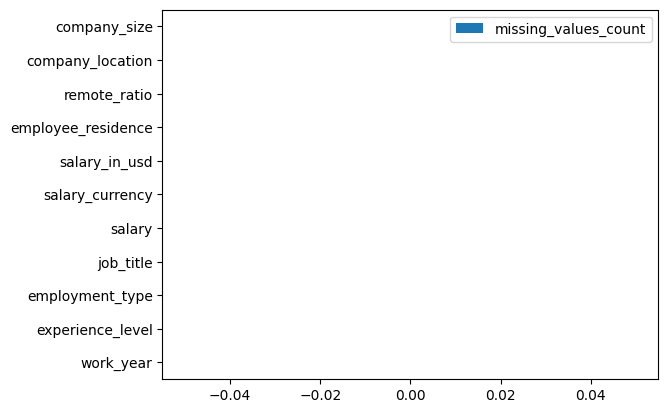

In [26]:
missing_values_df.plot(kind='barh');

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


## 1.2 Check Duplicate Data

### 1.2.1 Copy Data

In [28]:
dm = pd.DataFrame(
    data={
        'col1': [1, 2, 3],
        'col2': [4, 5, 6]
    }
)

dm

,col1,col2
0,1,4
1,2,5
2,3,6


In [29]:
dm1 = dm

In [30]:
dm1['col1'] = dm1['col1'] + 1

In [31]:
dm1

,col1,col2
0,2,4
1,3,5
2,4,6


In [32]:
dm

,col1,col2
0,2,4
1,3,5
2,4,6


In [33]:
# Salin data sebelum transformasi
df_copy = df.copy()

In [34]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [35]:
df.duplicated().sum()

np.int64(1171)

In [36]:
duplicated_row_mask = df.duplicated()
df[duplicated_row_mask].sort_values(by=list(df.columns))

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3120,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3586,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
3709,2021,MI,FT,Data Scientist,76760,EUR,90734,DE,50,DE,L
2041,2022,EN,FT,Data Analyst,50000,USD,50000,US,50,US,L
3272,2022,EN,FT,Data Engineer,40000,GBP,49253,GB,100,GB,M
1996,2022,EN,FT,Data Engineer,135000,USD,135000,US,0,US,M
2084,2022,EN,FT,Data Engineer,135000,USD,135000,US,0,US,M
2194,2022,EN,FT,Data Engineer,135000,USD,135000,US,0,US,M
2268,2022,EN,FT,Data Engineer,135000,USD,135000,US,0,US,M
2349,2022,EN,FT,Data Engineer,135000,USD,135000,US,0,US,M


In [92]:
duplicated_row_mask = df.duplicated(keep=False)
df[duplicated_row_mask].sort_values(by=list(df.columns))

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3119,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3120,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3502,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
3586,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
3665,2021,MI,FT,Data Scientist,76760,EUR,90734,DE,50,DE,L
3709,2021,MI,FT,Data Scientist,76760,EUR,90734,DE,50,DE,L
2023,2022,EN,FT,Data Analyst,50000,USD,50000,US,50,US,L
2041,2022,EN,FT,Data Analyst,50000,USD,50000,US,50,US,L
2451,2022,EN,FT,Data Engineer,40000,GBP,49253,GB,100,GB,M
3272,2022,EN,FT,Data Engineer,40000,GBP,49253,GB,100,GB,M


### 1.2.2 Delete Duplicates

In [38]:
# Menghapus duplikasi
print(f"Jumlah duplikasi sebelum dihapus: {df_copy.duplicated(keep='first').sum()}")

df_copy.drop_duplicates(keep='first', inplace=True)
print(f"Jumlah duplikasi setelah dihapus: {df_copy.duplicated().sum()}")

Jumlah duplikasi sebelum dihapus: 1171
Jumlah duplikasi setelah dihapus: 0


## 1.3 Check Unique Values in Each Column

### 1.3.1 Check Data Shape

In [39]:
df_copy.shape

(2584, 11)

### 1.3.2 Check Data Type

In [40]:
df_copy.dtypes

,0
work_year,int64
experience_level,object
employment_type,object
job_title,object
salary,int64
salary_currency,object
salary_in_usd,int64
employee_residence,object
remote_ratio,int64
company_location,object


In [41]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 242.2+ KB


### 1.3.3 Check Data Stats

In [42]:
df_copy.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,2584.000000,2.584000e+03,2584.000000,2584.000000
mean,2022.301084,2.103653e+05,133409.280186,50.483746
std,0.749179,8.080375e+05,67136.837329,48.163707
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,9.000000e+04,84975.000000,0.000000
50%,2022.000000,1.346300e+05,130000.000000,50.000000
75%,2023.000000,1.825625e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [93]:
df_copy.describe(include='object')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,2584,2584,2584,2584,2584,2584,2584
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,1554,2547,598,2107,1893,1929,2028


### 1.3.4 Check Unique Values

In [44]:
# for col in df_copy.columns:
#     if col == 'salary' or col == 'salary_in_usd':
#         continue
#     else:
#         print(f"{col}: {df_copy[col].nunique()}")
#         print(f"{df_copy[col].unique()}")
#         print("-*-"*20)

In [45]:
excepted_columns = [
    'salary',
    'salary_in_usd'
]

for col in df_copy.columns:
    if col not in excepted_columns:
        print(f"{col}: {df_copy[col].nunique()}")
        print(f"{df_copy[col].unique()}")
        print("-*-"*20)
        print("")

work_year: 4
[2023 2022 2020 2021]
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-

experience_level: 4
['SE' 'MI' 'EN' 'EX']
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-

employment_type: 4
['FT' 'CT' 'FL' 'PT']
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-

job_title: 93
['Principal Data Scientist' 'ML Engineer' 'Data Scientist'
 'Applied Scientist' 'Data Analyst' 'Data Modeler' 'Research Engineer'
 'Analytics Engineer' 'Business Intelligence Engineer'
 'Machine Learning Engineer' 'Data Strategist' 'Data Engineer'
 'Computer Vision Engineer' 'Data Quality Analyst'
 'Compliance Data Analyst' 'Data Architect'
 'Applied Machine Learning Engineer' 'AI Developer' 'Research Scientist'
 'Data Analytics Manager' 'Business Data Analyst' 'Applied Data Scientist'
 'Staff Data Analyst' 'ETL Engineer' 'Data DevOps Engineer' 'Head of Data'
 'Data Science Manager' 'Data Manager' 'Machine Learning Researcher'
 'Big Data Engineer' 'Data Specialist' 'Lead Da

### 1.3.5 Check Columns

In [46]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

## 1.4 Rename Value for Better Understanding

In [47]:
dict_exp_level = {
    'EN': 'Junior',
    'MI': 'Mid',
    'SE': 'Senior',
    'EX': 'Executive'
}

dict_employment_type = {
    'FT': 'Full Time',
    'PT': 'Part Time',
    'CT': 'Contract',
    'FL': 'Freelance'
}

dict_remote_ratio = {
    0: 'No Remote',
    50: 'Partially Remote',
    100: 'Fully Remote'
}

### 1.4.1 Replace Values

In [48]:
df_1 = df_copy.copy()

In [49]:
df_1.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [50]:
df_1['experience_level'] = (
    df_1['experience_level']
    .replace(dict_exp_level)
)

df_1['employment_type'] = (
    df_1['employment_type']
    .replace(dict_employment_type)
)

df_1['remote_ratio'] = (
    df_1['remote_ratio']
    .replace(dict_remote_ratio)
)

In [51]:
df_1.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,Senior,Full Time,Principal Data Scientist,80000,EUR,85847,ES,Fully Remote,ES,L
1,2023,Mid,Contract,ML Engineer,30000,USD,30000,US,Fully Remote,US,S
2,2023,Mid,Contract,ML Engineer,25500,USD,25500,US,Fully Remote,US,S
3,2023,Senior,Full Time,Data Scientist,175000,USD,175000,CA,Fully Remote,CA,M
4,2023,Senior,Full Time,Data Scientist,120000,USD,120000,CA,Fully Remote,CA,M
5,2023,Senior,Full Time,Applied Scientist,222200,USD,222200,US,No Remote,US,L
6,2023,Senior,Full Time,Applied Scientist,136000,USD,136000,US,No Remote,US,L
7,2023,Senior,Full Time,Data Scientist,219000,USD,219000,CA,No Remote,CA,M
8,2023,Senior,Full Time,Data Scientist,141000,USD,141000,CA,No Remote,CA,M
9,2023,Senior,Full Time,Data Scientist,147100,USD,147100,US,No Remote,US,M


### 1.4.2 Map Values

In [139]:
df_copy.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [140]:
df_2 = df_copy.copy()

In [141]:
list(df_2.columns).index('experience_level')

1

In [142]:
def detect_column_loc(df, col_name):
    return list(df.columns).index(col_name)

In [143]:
df_2.insert(
    loc=list(df_2.columns).index('experience_level') + 1,
    column="experience_level_desc",
    value=df_2['experience_level'].map(dict_exp_level)
)

In [144]:
df_2.head()

,work_year,experience_level,experience_level_desc,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,Senior,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,Mid,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,Mid,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,Senior,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,Senior,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [145]:
df_2.insert(
    loc=list(df_2.columns).index('employment_type') + 1,
    column="employment_type_desc",
    value=df_2['employment_type'].map(dict_employment_type)
)

In [146]:
df_2.head()

,work_year,experience_level,experience_level_desc,employment_type,employment_type_desc,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,Senior,FT,Full Time,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,Mid,CT,Contract,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,Mid,CT,Contract,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,Senior,FT,Full Time,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,Senior,FT,Full Time,Data Scientist,120000,USD,120000,CA,100,CA,M


In [147]:
df_2.insert(
    loc=list(df_2.columns).index('remote_ratio') + 1,
    column="remote_ratio_desc",
    value=df_2['remote_ratio'].map(dict_remote_ratio)
)

In [148]:
df_2.head()

,work_year,experience_level,experience_level_desc,employment_type,employment_type_desc,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,remote_ratio_desc,company_location,company_size
0,2023,SE,Senior,FT,Full Time,Principal Data Scientist,80000,EUR,85847,ES,100,Fully Remote,ES,L
1,2023,MI,Mid,CT,Contract,ML Engineer,30000,USD,30000,US,100,Fully Remote,US,S
2,2023,MI,Mid,CT,Contract,ML Engineer,25500,USD,25500,US,100,Fully Remote,US,S
3,2023,SE,Senior,FT,Full Time,Data Scientist,175000,USD,175000,CA,100,Fully Remote,CA,M
4,2023,SE,Senior,FT,Full Time,Data Scientist,120000,USD,120000,CA,100,Fully Remote,CA,M


## 1.5 Group the Job title

### Check Job Title

In [149]:
df_2['job_title'].unique()

array(['Principal Data Scientist', 'ML Engineer', 'Data Scientist',
       'Applied Scientist', 'Data Analyst', 'Data Modeler',
       'Research Engineer', 'Analytics Engineer',
       'Business Intelligence Engineer', 'Machine Learning Engineer',
       'Data Strategist', 'Data Engineer', 'Computer Vision Engineer',
       'Data Quality Analyst', 'Compliance Data Analyst',
       'Data Architect', 'Applied Machine Learning Engineer',
       'AI Developer', 'Research Scientist', 'Data Analytics Manager',
       'Business Data Analyst', 'Applied Data Scientist',
       'Staff Data Analyst', 'ETL Engineer', 'Data DevOps Engineer',
       'Head of Data', 'Data Science Manager', 'Data Manager',
       'Machine Learning Researcher', 'Big Data Engineer',
       'Data Specialist', 'Lead Data Analyst', 'BI Data Engineer',
       'Director of Data Science', 'Machine Learning Scientist',
       'MLOps Engineer', 'AI Scientist', 'Autonomous Vehicle Technician',
       'Applied Machine Learning Sc

### Grouping Function

In [63]:
# def assign_broader_category(job_title):

#     data_engineering = ["Data Engineer", "Data Analyst", "Analytics Engineer", "BI Data Analyst", "Business Data Analyst", "BI Developer", "BI Analyst", "Business Intelligence Engineer", "BI Data Engineer", "Power BI Developer"]
#     data_scientist = ["Data Scientist", "Applied Scientist", "Research Scientist", "3D Computer Vision Researcher", "Deep Learning Researcher", "AI/Computer Vision Engineer"]
#     machine_learning = ["Machine Learning Engineer", "ML Engineer", "Lead Machine Learning Engineer", "Principal Machine Learning Engineer"]
#     data_architecture = ["Data Architect", "Big Data Architect", "Cloud Data Architect", "Principal Data Architect"]
#     management = ["Data Science Manager", "Director of Data Science", "Head of Data Science", "Data Scientist Lead", "Head of Machine Learning", "Manager Data Management", "Data Analytics Manager"]

#     if job_title in data_engineering:
#         return "Data Engineering"
#     elif job_title in data_scientist:
#         return "Data Scientist"
#     elif job_title in machine_learning:
#         return "Machine Learning"
#     elif job_title in data_architecture:
#         return "Data Architecture"
#     elif job_title in management:
#         return "Management"
#     else:
#         return "Other"

In [150]:
category_mapping = {

      "Data Engineer": [
          "Data Engineer",
          "Analytics Engineer",
          "BI Data Analyst",
          "Business Data Analyst",
          "BI Developer",
          "BI Analyst",
          "Business Intelligence Engineer",
          "BI Data Engineer",
          "Power BI Developer",

          # Tambahan dari array
          "ETL Engineer",
          "ETL Developer",
          "Big Data Engineer",
          "Cloud Data Engineer",
          "Azure Data Engineer",
          "Cloud Database Engineer",
          "Data Infrastructure Engineer",
          "Data Operations Engineer",
          "Data DevOps Engineer",
          "Software Data Engineer",
          "Marketing Data Engineer",
          "Data Analytics Engineer",
          "Lead Data Engineer",
          "Principal Data Engineer"

      ],

      "Data Analyst": [
          # Dari mapping lama yang lebih tepat masuk analyst
          "Data Analyst",

          # Tambahan dari array
          "Data Quality Analyst",
          "Compliance Data Analyst",
          "Staff Data Analyst",
          "Lead Data Analyst",
          "Financial Data Analyst",
          "Finance Data Analyst",
          "Principal Data Analyst",
          "Product Data Analyst",
          "Marketing Data Analyst",
          "Insight Analyst",
          "Data Analytics Specialist",
          "Data Analytics Consultant",
          "Data Operations Analyst",
          "Data Specialist"
    ],

      "Data Scientist": [
          "Data Scientist",
          "Applied Scientist",
          "Research Scientist",
          "3D Computer Vision Researcher",
          "Deep Learning Researcher",
          "AI/Computer Vision Engineer",

          # Tambahan dari array
          "Principal Data Scientist",
          "Applied Data Scientist",
          "Staff Data Scientist",
          "Lead Data Scientist",
          "Product Data Scientist",
          "Data Science Consultant",
          "Data Science Engineer",
          "Machine Learning Scientist",
          "Machine Learning Researcher",
          "Applied Machine Learning Scientist",
          "AI Scientist",
          "Research Engineer",
          "Computer Vision Engineer",
          "Deep Learning Engineer",
          "NLP Engineer"
      ],

      "ML Engineer": [
          "Machine Learning Engineer",
          "ML Engineer",
          "Lead Machine Learning Engineer",
          "Principal Machine Learning Engineer",

          # Tambahan dari array
          "Applied Machine Learning Engineer",
          "Machine Learning Infrastructure Engineer",
          "Machine Learning Software Engineer",
          "Machine Learning Research Engineer",
          "Machine Learning Developer",
          "MLOps Engineer",
          "AI Developer",
          "AI Programmer",
          "Computer Vision Software Engineer"
      ],

      "Data Architect": [
          "Data Architect",
          "Big Data Architect",
          "Cloud Data Architect",
          "Principal Data Architect",

          # Tambahan dari array
          "Data Modeler",
          "Data Strategist",
          "Data Management Specialist"
      ],

      "Manager": [
          "Data Science Manager",
          "Director of Data Science",
          "Head of Data Science",
          "Data Scientist Lead",
          "Head of Machine Learning",
          "Manager Data Management",
          "Data Analytics Manager",

          # Tambahan dari array
          "Head of Data",
          "Data Manager",
          "Data Science Lead",
          "Data Analytics Lead",
          "Data Lead",
          "Data Science Tech Lead",
          "Machine Learning Manager"
    ],

    "Other": [
        "Autonomous Vehicle Technician"
    ]


  }


def assign_broader_category(job_title, mapper):
  """
    Assigns a broader category to a given job title.

    Args:
      job_title (str): The job title to categorize.

    Returns:
      str: The broader category the job title belongs to, or "Other" if no
      match is found.
    """

  for category, titles in category_mapping.items():
    if job_title in titles:
      return category

  return "Other"

In [151]:
df_2.insert(
    loc=list(df_2.columns).index('job_title') + 1,
    column="job_title_simplified",
    value=df_2['job_title'].apply(lambda x: assign_broader_category(x, category_mapping))
)

In [97]:
df_2.head()

,work_year,experience_level,experience_level_desc,employment_type,employment_type_desc,job_title,job_title_simplified,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,remote_ratio_desc,company_location,company_size,adjusted_salary
0,2023,SE,Senior,FT,Full Time,Principal Data Scientist,Other,80000,EUR,85847,ES,100,Fully Remote,ES,L,85847.0
1,2023,MI,Mid,CT,Contract,ML Engineer,ML Engineer,30000,USD,30000,US,100,Fully Remote,US,S,30000.0
2,2023,MI,Mid,CT,Contract,ML Engineer,ML Engineer,25500,USD,25500,US,100,Fully Remote,US,S,25500.0
3,2023,SE,Senior,FT,Full Time,Data Scientist,Data Scientist,175000,USD,175000,CA,100,Fully Remote,CA,M,175000.0
4,2023,SE,Senior,FT,Full Time,Data Scientist,Data Scientist,120000,USD,120000,CA,100,Fully Remote,CA,M,120000.0


In [152]:
other_mask = df_2['job_title_simplified'] == 'Other'

In [154]:
df_2[other_mask]['job_title'].unique()

array(['Autonomous Vehicle Technician'], dtype=object)

In [155]:
job_title_category_map = category_mapping = {

    "Data Engineer": [
        # Mapping lama
        "Data Engineer",
        "Analytics Engineer",
        "BI Data Analyst",
        "Business Data Analyst",
        "BI Developer",
        "BI Analyst",
        "Business Intelligence Engineer",
        "BI Data Engineer",
        "Power BI Developer",

        # Tambahan dari array
        "ETL Engineer",
        "ETL Developer",
        "Big Data Engineer",
        "Cloud Data Engineer",
        "Azure Data Engineer",
        "Cloud Database Engineer",
        "Data Infrastructure Engineer",
        "Data Operations Engineer",
        "Data DevOps Engineer",
        "Software Data Engineer",
        "Marketing Data Engineer",
        "Data Analytics Engineer",
        "Lead Data Engineer",
        "Principal Data Engineer"
    ],

    "Data Analyst": [
        # Dari mapping lama yang lebih tepat masuk analyst
        "Data Analyst",

        # Tambahan dari array
        "Data Quality Analyst",
        "Compliance Data Analyst",
        "Staff Data Analyst",
        "Lead Data Analyst",
        "Financial Data Analyst",
        "Finance Data Analyst",
        "Principal Data Analyst",
        "Product Data Analyst",
        "Marketing Data Analyst",
        "Insight Analyst",
        "Data Analytics Specialist",
        "Data Analytics Consultant",
        "Data Operations Analyst",
        "Data Specialist"
    ],

    "Data Scientist": [
        # Mapping lama
        "Data Scientist",
        "Applied Scientist",
        "Research Scientist",
        "3D Computer Vision Researcher",
        "Deep Learning Researcher",
        "AI/Computer Vision Engineer",

        # Tambahan dari array
        "Principal Data Scientist",
        "Applied Data Scientist",
        "Staff Data Scientist",
        "Lead Data Scientist",
        "Product Data Scientist",
        "Data Science Consultant",
        "Data Science Engineer",
        "Machine Learning Scientist",
        "Machine Learning Researcher",
        "Applied Machine Learning Scientist",
        "AI Scientist",
        "Research Engineer",
        "Computer Vision Engineer",
        "Deep Learning Engineer",
        "NLP Engineer"
    ],

    "ML Engineer": [
        # Mapping lama
        "Machine Learning Engineer",
        "ML Engineer",
        "Lead Machine Learning Engineer",
        "Principal Machine Learning Engineer",

        # Tambahan dari array
        "Applied Machine Learning Engineer",
        "Machine Learning Infrastructure Engineer",
        "Machine Learning Software Engineer",
        "Machine Learning Research Engineer",
        "Machine Learning Developer",
        "MLOps Engineer",
        "AI Developer",
        "AI Programmer",
        "Computer Vision Software Engineer"
    ],

    "Data Architect": [
        # Mapping lama
        "Data Architect",
        "Big Data Architect",
        "Cloud Data Architect",
        "Principal Data Architect",

        # Tambahan dari array
        "Data Modeler",
        "Data Strategist",
        "Data Management Specialist"
    ],

    "Manager": [
        # Mapping lama
        "Data Science Manager",
        "Director of Data Science",
        "Head of Data Science",
        "Data Scientist Lead",
        "Head of Machine Learning",
        "Manager Data Management",
        "Data Analytics Manager",

        # Tambahan dari array
        "Head of Data",
        "Data Manager",
        "Data Science Lead",
        "Data Analytics Lead",
        "Data Lead",
        "Data Science Tech Lead",
        "Machine Learning Manager"
    ],

    "Other": [
        "Autonomous Vehicle Technician"
    ]
}

## 1.6 Adjust Salary to Present Values

### Inflation Rate

In [156]:
# Inflation rates
us_inflation_rates = {
    2019: 0.0181,
    2020: 0.0123,
    2021: 0.0470,
    2022: 0.065
}

global_inflation_rates = {
    2019: 0.0219,
    2020: 0.0192,
    2021: 0.0350,
    2022: 0.088
}

def adjust_salary(df):

    year = df['work_year']
    ori_salary = df['salary_in_usd']
    currency = df['salary_currency']

    if year == 2023:
        return ori_salary
    else:
        adjusted_salary = ori_salary
        for y in range(year, 2023):
            if currency == 'USD':
                inflation_rate = us_inflation_rates[y]
            else:
                inflation_rate = global_inflation_rates[y]

            adjusted_salary = adjusted_salary * (1 + inflation_rate)

    return adjusted_salary

In [157]:
df_2['adjusted_salary'] = df_2.apply(adjust_salary, axis=1)

In [71]:
# df_2.insert(
#     loc=list(df_2.columns).index('salary_in_usd') + 1,
#     column="adjusted_salary",
#     value=df_2.apply(adjust_salary, axis=1)
# )

In [72]:
df_2.head()

,work_year,experience_level,experience_level_desc,employment_type,employment_type_desc,job_title,job_title_simplified,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,remote_ratio_desc,company_location,company_size,adjusted_salary
0,2023,SE,Senior,FT,Full Time,Principal Data Scientist,Other,80000,EUR,85847,ES,100,Fully Remote,ES,L,85847.0
1,2023,MI,Mid,CT,Contract,ML Engineer,ML Engineer,30000,USD,30000,US,100,Fully Remote,US,S,30000.0
2,2023,MI,Mid,CT,Contract,ML Engineer,ML Engineer,25500,USD,25500,US,100,Fully Remote,US,S,25500.0
3,2023,SE,Senior,FT,Full Time,Data Scientist,Data Scientist,175000,USD,175000,CA,100,Fully Remote,CA,M,175000.0
4,2023,SE,Senior,FT,Full Time,Data Scientist,Data Scientist,120000,USD,120000,CA,100,Fully Remote,CA,M,120000.0


# SOAL No.1
Show the median adjusted data scientist salary, for each experience level

## JAWABAN No.1

In [158]:
median_salary_by_experience = (
    df_2.groupby("experience_level")
      .agg(
          jumlah_data=("salary_in_usd", "count"),
          median_adjusted_salary=("salary_in_usd", "median")
      )
      .reset_index()
      .sort_values(by="median_adjusted_salary", ascending=True)
)

median_salary_by_experience

,experience_level,jumlah_data,median_adjusted_salary
0,EN,270,61900.0
2,MI,664,95000.0
3,SE,1554,148800.0
1,EX,96,189618.5


# SOAL No. 2
Show the number of records for each company_location, sorted descending

## JAWABAN No.2

In [122]:
company_location_counts = (
    df_2["company_location"]
    .value_counts()
    .reset_index()
)

company_location_counts.columns = ["company_location", "jumlah_record"]

company_location_counts

,company_location,jumlah_record
0,US,1929
1,GB,155
2,CA,83
3,IN,57
4,DE,55
5,ES,44
6,FR,33
7,BR,15
8,AU,14
9,PT,14


# SOAL No.3
From this data, show the median adjusted salary of employee who works for company located in Indonesia, do you think that value represents the salary in Indonesia? why? why not?

## JAWABAN No.3

In [136]:
# Filter data perusahaan yang berlokasi di Indonesia

indonesia_data = df_2[df_2["company_location"] == "ID"]

indonesia_data

,work_year,experience_level,experience_level_desc,employment_type,employment_type_desc,job_title,job_title_simplified,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,remote_ratio_desc,company_location,company_size
3061,2022,MI,Mid,FT,Full Time,Data Scientist,Data Scientist,4200000,INR,53416,IN,100,Fully Remote,ID,L
3139,2022,EN,Junior,FT,Full Time,Data Analyst,Data Engineer,15000,USD,15000,ID,0,No Remote,ID,L


In [133]:
# Median adjusted salary untuk company_location Indonesia

median_salary_indonesia = indonesia_data["salary_in_usd"].median()

median_salary_indonesia

34208.0

In [135]:
# Jumlah data untuk company_location Indonesia

jumlah_data_indonesia = indonesia_data.shape[0]

jumlah_data_indonesia

2

In [134]:
# Tampilkan data penting saja untuk Indonesia

indonesia_summary = indonesia_data[
    [
        "work_year",
        "experience_level",
        "employment_type",
        "job_title",
        "salary_in_usd",
        "employee_residence",
        "company_location",
        "company_size"
    ]
]

indonesia_summary

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,company_location,company_size
3061,2022,MI,FT,Data Scientist,53416,IN,ID,L
3139,2022,EN,FT,Data Analyst,15000,ID,ID,L


**Kesimpulan** <br>
................

In [167]:
# Menampilkan median gaji
print(f"Median Adjusted Salary of Employees in Indonesia: {median_salary_indonesia} USD")

# Analisis tambahan apakah nilai median mencerminkan gaji di Indonesia
# Median dihitung hanya dari dua nilai, jadi kita analisis apakah ini representatif
if median_salary_indonesia > 20000:  # Ini adalah ambang batas kasar untuk gaji tinggi
    conclusion = f"Median adjusted salary ini kemungkinan lebih tinggi daripada gaji tipikal di Indonesia, mungkin karena adanya peran dengan gaji tinggi di perusahaan multinasional."
else:
    conclusion = f"Median adjusted salary ini mungkin lebih mewakili gaji tipikal di Indonesia, meskipun lebih banyak data diperlukan untuk penilaian yang lebih akurat."

# Print the conclusion
print("\nConclusion:")
print(conclusion)

Median Adjusted Salary of Employees in Indonesia: 34208.0 USD

Conclusion:
Median adjusted salary ini kemungkinan lebih tinggi daripada gaji tipikal di Indonesia, mungkin karena adanya peran dengan gaji tinggi di perusahaan multinasional.
